In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import glob
import torch
import torchvision
import numpy as np
import pandas as pd

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

print("\nKaggle input directories:")
for x in glob.glob("/kaggle/input/*"):
    print(x)

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB

Kaggle input directories:
/kaggle/input/datasets


In [2]:
!git clone https://github.com/facebookresearch/ijepa.git /kaggle/working/ijepa
%cd /kaggle/working/ijepa
!ls

Cloning into '/kaggle/working/ijepa'...
remote: Enumerating objects: 32, done.
remote: Total 32 (delta 0), reused 0 (delta 0), pack-reused 32 (from 1)
Receiving objects: 100% (32/32), 33.88 KiB | 8.47 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/kaggle/working/ijepa
CODE_OF_CONDUCT.md  CONTRIBUTING.md  main_distributed.py  README.md
configs		    LICENSE	     main.py		  src


In [6]:
!pip install -q pyyaml opencv-python submitit

In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level < 4:
        print("  " * level + os.path.basename(root) + "/")
        for f in files[:10]:
            print("  " * (level + 1) + f)

input/
  datasets/
    ambarish/
      breakhis/
        Folds.csv


In [8]:
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/kaggle/input")

extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

image_paths = []

for p in DATA_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in extensions:
        image_paths.append(str(p))

print("Total images found:", len(image_paths))

for p in image_paths[:20]:
    print(p)

Total images found: 7909
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-012.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-009.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-006.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-011.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-004.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200

In [9]:
from collections import Counter

parts = []

for p in image_paths:
    parts.extend(Path(p).parts[-6:])

print(Counter(parts).most_common(50))

[('SOB', 7909), ('malignant', 5429), ('ductal_carcinoma', 3451), ('benign', 2480), ('100X', 2081), ('200X', 2013), ('40X', 1995), ('400X', 1820), ('fibroadenoma', 1014), ('mucinous_carcinoma', 792), ('lobular_carcinoma', 626), ('tubular_adenoma', 569), ('papillary_carcinoma', 560), ('phyllodes_tumor', 453), ('adenosis', 444), ('SOB_B_PT_14-21998AB', 235), ('SOB_M_LC_14-15570', 201), ('SOB_M_MC_14-16456', 178), ('SOB_B_PT_14-22704', 158), ('SOB_M_DC_14-9461', 155), ('SOB_M_DC_14-12312', 146), ('SOB_M_DC_14-13993', 145), ('SOB_M_DC_14-2773', 144), ('SOB_B_F_14-14134', 142), ('SOB_M_PC_14-19440', 142), ('SOB_B_F_14-21998CD', 137), ('SOB_M_DC_14-16716', 137), ('SOB_B_A_14-22549CD', 132), ('SOB_B_TA_14-16184', 132), ('SOB_M_DC_14-14946', 131), ('SOB_B_A_14-22549G', 130), ('SOB_M_DC_14-17614', 129), ('SOB_M_PC_14-15704', 127), ('SOB_B_F_14-9133', 126), ('SOB_M_LC_14-15570C', 125), ('SOB_M_DC_14-20629', 125), ('SOB_B_TA_14-16184CD', 124), ('SOB_M_LC_14-13412', 123), ('SOB_M_DC_14-13412', 123)

In [10]:
rows = []

for p in image_paths:
    lower = p.lower()

    if "benign" in lower:
        label = 0
    elif "malignant" in lower:
        label = 1
    else:
        label = -1

    rows.append({
        "path": p,
        "label": label
    })

df = pd.DataFrame(rows)

print(df.head())
print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nUnknown:")
print((df["label"] == -1).sum())

                                                path  label
0  /kaggle/input/datasets/ambarish/breakhis/BreaK...      0
1  /kaggle/input/datasets/ambarish/breakhis/BreaK...      0
2  /kaggle/input/datasets/ambarish/breakhis/BreaK...      0
3  /kaggle/input/datasets/ambarish/breakhis/BreaK...      0
4  /kaggle/input/datasets/ambarish/breakhis/BreaK...      0

Label distribution:
label
1    5429
0    2480
Name: count, dtype: int64

Unknown:
0


In [11]:
# ============================================================
# I-JEPA + BreakHis : Kaggle Setup
# ============================================================

import os
import sys
import glob
import math
import random
import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("DEVICE INFORMATION")
print("=" * 60)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

# ------------------------------------------------------------
# I-JEPA repository
# ------------------------------------------------------------

IJEP_ROOT = "/kaggle/working/ijepa"

if not os.path.exists(IJEP_ROOT):
    !git clone -q https://github.com/facebookresearch/ijepa.git /kaggle/working/ijepa

print("\nI-JEPA repository:", IJEP_ROOT)

# ------------------------------------------------------------
# Dataset discovery
# ------------------------------------------------------------

DATA_ROOT = Path("/kaggle/input")

extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

image_paths = []

for p in DATA_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in extensions:
        image_paths.append(str(p))

print("\nImages found:", len(image_paths))

# ------------------------------------------------------------
# Show sample paths
# ------------------------------------------------------------

print("\nSample image paths:")

for p in image_paths[:15]:
    print(p)

# ------------------------------------------------------------
# Create dataframe
# ------------------------------------------------------------

rows = []

for p in image_paths:

    lower = p.lower()

    if "benign" in lower:
        label = 0

    elif "malignant" in lower:
        label = 1

    else:
        label = -1

    rows.append({
        "path": p,
        "label": label
    })

df = pd.DataFrame(rows)

print("\nDataFrame:")
print(df.head())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nUnknown labels:", (df["label"] == -1).sum())

# ------------------------------------------------------------
# Memory cleanup
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nSetup complete.")

DEVICE INFORMATION
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

I-JEPA repository: /kaggle/working/ijepa

Images found: 7909

Sample image paths:
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-012.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-009.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-006.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-011.png
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29

In [12]:
class BreakHisDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        path = self.df.iloc[idx]["path"]

        image = Image.open(path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image

In [13]:
ijepa_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

In [14]:
ssl_df = df[df["label"] != -1].copy()

ssl_dataset = BreakHisDataset(
    ssl_df,
    transform=ijepa_transform
)

print("SSL images:", len(ssl_dataset))


SSL images: 7909


In [15]:
BATCH_SIZE = 16

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

images = next(iter(ssl_loader))

print("Batch shape:", images.shape)

Batch shape: torch.Size([16, 3, 224, 224])


In [16]:
images = images.to(device)

print(images.device)
print(images.shape)

cuda:0
torch.Size([16, 3, 224, 224])


In [17]:
class PatchEmbedding(nn.Module):

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=384
    ):

        super().__init__()

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.num_patches = (
            image_size // patch_size
        ) ** 2

    def forward(self, x):

        x = self.proj(x)

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

In [27]:
# ============================================================
# CELL 18
# Vision Transformer Encoder
# ============================================================

class VisionTransformerEncoder(nn.Module):

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        embed_dim=384,
        depth=6,
        num_heads=6,
        mlp_ratio=4.0
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # Image -> patch embeddings
        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            embed_dim=embed_dim
        )

        self.num_patches = self.patch_embed.num_patches

        # Positional embeddings
        self.pos_embed = nn.Parameter(
            torch.zeros(
                1,
                self.num_patches,
                embed_dim
            )
        )

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=False
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)

        # Initialize positional embedding
        nn.init.trunc_normal_(
            self.pos_embed,
            std=0.02
        )

    def forward(
        self,
        x,
        patch_indices=None
    ):

        # ----------------------------------------------------
        # Convert image into patch tokens
        # ----------------------------------------------------

        x = self.patch_embed(x)

        # x:
        # [B, 196, 384]

        # ----------------------------------------------------
        # If patch_indices are supplied,
        # keep ONLY those patches.
        # ----------------------------------------------------

        if patch_indices is not None:

            B = x.shape[0]
            D = x.shape[-1]

            indices = patch_indices.unsqueeze(-1).expand(
                -1,
                -1,
                D
            )

            x = torch.gather(
                x,
                dim=1,
                index=indices
            )

            # Corresponding positional embeddings
            pos = self.pos_embed.expand(
                B,
                -1,
                -1
            )

            pos = torch.gather(
                pos,
                dim=1,
                index=indices
            )

            x = x + pos

        else:

            x = x + self.pos_embed

        # ----------------------------------------------------
        # Transformer
        # ----------------------------------------------------

        x = self.transformer(x)

        # ----------------------------------------------------
        # Final normalization
        # ----------------------------------------------------

        x = self.norm(x)

        return x

In [28]:
# ============================================================
# CELL 19
# I-JEPA Predictor
# ============================================================

class IJEPA_Predictor(nn.Module):

    def __init__(
        self,
        num_patches=196,
        embed_dim=384,
        depth=4,
        num_heads=6,
        mlp_ratio=4.0
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_patches = num_patches

        # Positional embedding for target locations
        self.pos_embed = nn.Parameter(
            torch.zeros(
                1,
                num_patches,
                embed_dim
            )
        )

        # Transformer predictor
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=False
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)

        # Initialize
        nn.init.trunc_normal_(
            self.pos_embed,
            std=0.02
        )

    def forward(
        self,
        context,
        target_indices
    ):

        B = context.shape[0]

        D = context.shape[-1]

        # ----------------------------------------------------
        # Get target positional embeddings
        # ----------------------------------------------------

        target_pos = self.pos_embed.expand(
            B,
            -1,
            -1
        )

        indices = target_indices.unsqueeze(-1).expand(
            -1,
            -1,
            D
        )

        target_pos = torch.gather(
            target_pos,
            dim=1,
            index=indices
        )

        # ----------------------------------------------------
        # Predictor input
        #
        # context representation
        # +
        # target positional information
        # ----------------------------------------------------

        x = torch.cat(
            [
                context,
                target_pos
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Transformer
        # ----------------------------------------------------

        x = self.transformer(x)

        # ----------------------------------------------------
        # Keep only target positions
        # ----------------------------------------------------

        target_len = target_pos.shape[1]

        prediction = x[:, -target_len:]

        prediction = self.norm(prediction)

        return prediction

In [29]:
# ============================================================
# CELL 20
# Create I-JEPA Models
# ============================================================

context_encoder = VisionTransformerEncoder(
    image_size=224,
    patch_size=16,
    embed_dim=384,
    depth=6,
    num_heads=6
).to(device)

target_encoder = VisionTransformerEncoder(
    image_size=224,
    patch_size=16,
    embed_dim=384,
    depth=6,
    num_heads=6
).to(device)

predictor = IJEPA_Predictor(
    num_patches=196,
    embed_dim=384,
    depth=4,
    num_heads=6
).to(device)

# ------------------------------------------------------------
# Target encoder starts with same weights
# ------------------------------------------------------------

target_encoder.load_state_dict(
    context_encoder.state_dict()
)

# ------------------------------------------------------------
# Target encoder is NOT trained by backpropagation
# ------------------------------------------------------------

for param in target_encoder.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Print parameter counts
# ------------------------------------------------------------

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )

print(
    "Context encoder:",
    f"{count_parameters(context_encoder)/1e6:.2f}M parameters"
)

print(
    "Target encoder:",
    f"{count_parameters(target_encoder)/1e6:.2f}M parameters"
)

print(
    "Predictor:",
    f"{count_parameters(predictor)/1e6:.2f}M parameters"
)

print("\nModels created successfully.")

Context encoder: 11.02M parameters
Target encoder: 11.02M parameters
Predictor: 7.17M parameters

Models created successfully.


In [30]:
images = next(iter(ssl_loader)).to(device)

with torch.no_grad():
    output = context_encoder(images)

print("Input :", images.shape)
print("Output:", output.shape)

Input : torch.Size([16, 3, 224, 224])
Output: torch.Size([16, 196, 384])


In [31]:
# ============================================================
# CELL 21
# Test Context Encoder
# ============================================================

images = next(iter(ssl_loader))

images = images.to(
    device,
    non_blocking=True
)

B = images.shape[0]

# Example: keep first 160 patches
context_indices = torch.arange(
    160,
    device=device
).unsqueeze(0).repeat(
    B,
    1
)

with torch.no_grad():

    context_output = context_encoder(
        images,
        context_indices
    )

print("Images:")
print(images.shape)

print("\nContext indices:")
print(context_indices.shape)

print("\nContext encoder output:")
print(context_output.shape)

Images:
torch.Size([16, 3, 224, 224])

Context indices:
torch.Size([16, 160])

Context encoder output:
torch.Size([16, 160, 384])


In [32]:
# ============================================================
# CELL 22
# Spatial Block Masking
# ============================================================

def create_spatial_masks(
    batch_size,
    grid_size=14,
    target_size=6,
    device="cuda"
):

    num_patches = grid_size * grid_size

    all_indices = torch.arange(
        num_patches,
        device=device
    )

    context_indices_list = []
    target_indices_list = []

    for _ in range(batch_size):

        # ----------------------------------------------------
        # Random top-left position
        # ----------------------------------------------------

        max_start = grid_size - target_size

        row_start = random.randint(
            0,
            max_start
        )

        col_start = random.randint(
            0,
            max_start
        )

        # ----------------------------------------------------
        # Create target block
        # ----------------------------------------------------

        target_indices = []

        for r in range(
            row_start,
            row_start + target_size
        ):

            for c in range(
                col_start,
                col_start + target_size
            ):

                target_indices.append(
                    r * grid_size + c
                )

        target_indices = torch.tensor(
            target_indices,
            device=device,
            dtype=torch.long
        )

        # ----------------------------------------------------
        # Context = everything except target
        # ----------------------------------------------------

        mask = torch.ones(
            num_patches,
            dtype=torch.bool,
            device=device
        )

        mask[target_indices] = False

        context_indices = all_indices[mask]

        context_indices_list.append(
            context_indices
        )

        target_indices_list.append(
            target_indices
        )

    context_indices = torch.stack(
        context_indices_list
    )

    target_indices = torch.stack(
        target_indices_list
    )

    return (
        context_indices,
        target_indices
    )

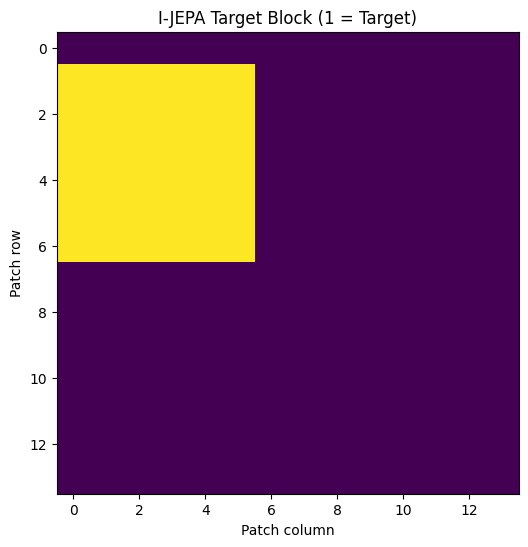

In [33]:
# ============================================================
# CELL 23
# Visualize Spatial Mask
# ============================================================

import matplotlib.pyplot as plt

context_idx, target_idx = create_spatial_masks(
    batch_size=1,
    grid_size=14,
    target_size=6,
    device=device
)

target = target_idx[0].cpu().numpy()

mask_image = np.zeros(
    (14, 14)
)

for idx in target:

    row = idx // 14
    col = idx % 14

    mask_image[row, col] = 1

plt.figure(figsize=(6, 6))

plt.imshow(mask_image)

plt.title(
    "I-JEPA Target Block (1 = Target)"
)

plt.xlabel("Patch column")
plt.ylabel("Patch row")

plt.show()

In [34]:
# ============================================================
# CELL 24
# EMA Update
# ============================================================

@torch.no_grad()
def update_target_encoder(
    context_encoder,
    target_encoder,
    tau=0.996
):

    for context_param, target_param in zip(
        context_encoder.parameters(),
        target_encoder.parameters()
    ):

        target_param.data.mul_(tau)

        target_param.data.add_(
            (1.0 - tau)
            * context_param.data
        )

In [35]:
# ============================================================
# CELL 25
# JEPA Loss
# ============================================================

def jepa_loss(
    prediction,
    target
):

    prediction = F.normalize(
        prediction,
        dim=-1
    )

    target = F.normalize(
        target,
        dim=-1
    )

    loss = 2 - 2 * (
        prediction * target
    ).sum(
        dim=-1
    ).mean()

    return loss

In [38]:
# ============================================================
# CELL 26
# One I-JEPA Training Step
# ============================================================

def train_one_ijepa_step(
    images,
    context_encoder,
    target_encoder,
    predictor,
    optimizer,
    tau=0.996
):

    images = images.to(
        device,
        non_blocking=True
    )

    B = images.shape[0]

    # --------------------------------------------------------
    # 1. Create spatial context/target masks
    # --------------------------------------------------------

    context_indices, target_indices = (
        create_spatial_masks(
            batch_size=B,
            grid_size=14,
            target_size=6,
            device=device
        )
    )

    # --------------------------------------------------------
    # 2. TARGET ENCODER
    #
    # Target encoder sees the complete image.
    # No gradients.
    # --------------------------------------------------------

    with torch.no_grad():

        target_tokens = target_encoder(
            images
        )

        target_representation = gather_tokens(
            target_tokens,
            target_indices
        )

    # --------------------------------------------------------
    # 3. CONTEXT ENCODER
    #
    # Context encoder sees ONLY context patches.
    # --------------------------------------------------------

    context_representation = context_encoder(
        images,
        context_indices
    )

    # --------------------------------------------------------
    # 4. PREDICT TARGET REPRESENTATION
    # --------------------------------------------------------

    prediction = predictor(
        context_representation,
        target_indices
    )

    # --------------------------------------------------------
    # 5. Calculate JEPA loss
    # --------------------------------------------------------

    loss = jepa_loss(
        prediction,
        target_representation
    )

    # --------------------------------------------------------
    # 6. Backpropagation
    # --------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    # --------------------------------------------------------
    # 7. Gradient clipping
    # --------------------------------------------------------

    torch.nn.utils.clip_grad_norm_(
        list(context_encoder.parameters())
        + list(predictor.parameters()),
        max_norm=1.0
    )

    # --------------------------------------------------------
    # 8. Update context encoder + predictor
    # --------------------------------------------------------

    optimizer.step()

    # --------------------------------------------------------
    # 9. EMA update target encoder
    # --------------------------------------------------------

    update_target_encoder(
        context_encoder,
        target_encoder,
        tau=tau
    )

    return loss.item()

In [39]:
# ============================================================
# CELL 27
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    list(context_encoder.parameters())
    +
    list(predictor.parameters()),
    lr=1e-4,
    weight_decay=0.05
)

print("Optimizer created.")

Optimizer created.


In [41]:
# ============================================================
# CELL 26 + 27
# COMPLETE I-JEPA TRAINING FUNCTIONS + OPTIMIZER
# ============================================================

import random
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# 1. Gather selected patch tokens
# ------------------------------------------------------------

def gather_tokens(tokens, indices):
    """
    tokens:
        [B, N, D]

    indices:
        [B, K]

    returns:
        [B, K, D]
    """

    B, N, D = tokens.shape

    indices = indices.unsqueeze(-1).expand(
        -1,
        -1,
        D
    )

    return torch.gather(
        tokens,
        dim=1,
        index=indices
    )


# ------------------------------------------------------------
# 2. Create spatial target block
# ------------------------------------------------------------

def create_spatial_masks(
    batch_size,
    grid_size=14,
    target_size=6,
    device="cuda"
):

    num_patches = grid_size * grid_size

    all_indices = torch.arange(
        num_patches,
        device=device
    )

    context_indices_list = []
    target_indices_list = []

    for _ in range(batch_size):

        # Random target location
        max_start = grid_size - target_size

        row_start = random.randint(
            0,
            max_start
        )

        col_start = random.randint(
            0,
            max_start
        )

        # ----------------------------------------------------
        # Target block
        # ----------------------------------------------------

        target_indices = []

        for r in range(
            row_start,
            row_start + target_size
        ):

            for c in range(
                col_start,
                col_start + target_size
            ):

                target_indices.append(
                    r * grid_size + c
                )

        target_indices = torch.tensor(
            target_indices,
            dtype=torch.long,
            device=device
        )

        # ----------------------------------------------------
        # Context = all remaining patches
        # ----------------------------------------------------

        mask = torch.ones(
            num_patches,
            dtype=torch.bool,
            device=device
        )

        mask[target_indices] = False

        context_indices = all_indices[mask]

        context_indices_list.append(
            context_indices
        )

        target_indices_list.append(
            target_indices
        )

    context_indices = torch.stack(
        context_indices_list
    )

    target_indices = torch.stack(
        target_indices_list
    )

    return (
        context_indices,
        target_indices
    )


# ------------------------------------------------------------
# 3. EMA target encoder update
# ------------------------------------------------------------

@torch.no_grad()
def update_target_encoder(
    context_encoder,
    target_encoder,
    tau=0.996
):

    for context_param, target_param in zip(
        context_encoder.parameters(),
        target_encoder.parameters()
    ):

        target_param.data.mul_(tau)

        target_param.data.add_(
            (1.0 - tau)
            * context_param.data
        )


# ------------------------------------------------------------
# 4. JEPA loss
# ------------------------------------------------------------

def jepa_loss(
    prediction,
    target
):

    # Normalize representation vectors
    prediction = F.normalize(
        prediction,
        dim=-1
    )

    target = F.normalize(
        target,
        dim=-1
    )

    # Cosine-distance style loss
    loss = 2 - 2 * (
        prediction * target
    ).sum(
        dim=-1
    ).mean()

    return loss


# ------------------------------------------------------------
# 5. COMPLETE I-JEPA TRAINING STEP
# ------------------------------------------------------------

def train_one_ijepa_step(
    images,
    context_encoder,
    target_encoder,
    predictor,
    optimizer,
    tau=0.996
):

    # --------------------------------------------------------
    # Move images to GPU
    # --------------------------------------------------------

    images = images.to(
        device,
        non_blocking=True
    )

    B = images.shape[0]

    # --------------------------------------------------------
    # Create spatial context + target masks
    # --------------------------------------------------------

    context_indices, target_indices = (
        create_spatial_masks(
            batch_size=B,
            grid_size=14,
            target_size=6,
            device=device
        )
    )

    # --------------------------------------------------------
    # TARGET ENCODER
    #
    # Target encoder sees the complete image.
    #
    # No gradients are calculated here.
    # --------------------------------------------------------

    with torch.no_grad():

        target_tokens = target_encoder(
            images
        )

        target_representation = gather_tokens(
            target_tokens,
            target_indices
        )

    # --------------------------------------------------------
    # CONTEXT ENCODER
    #
    # IMPORTANT:
    # It receives ONLY context patches.
    # --------------------------------------------------------

    context_representation = context_encoder(
        images,
        context_indices
    )

    # --------------------------------------------------------
    # PREDICTOR
    #
    # Predict representation of target patches.
    # --------------------------------------------------------

    prediction = predictor(
        context_representation,
        target_indices
    )

    # --------------------------------------------------------
    # JEPA LOSS
    # --------------------------------------------------------

    loss = jepa_loss(
        prediction,
        target_representation
    )

    # --------------------------------------------------------
    # Clear old gradients
    # --------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )

    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    loss.backward()

    # --------------------------------------------------------
    # Gradient clipping
    # --------------------------------------------------------

    torch.nn.utils.clip_grad_norm_(
        list(context_encoder.parameters())
        +
        list(predictor.parameters()),
        max_norm=1.0
    )

    # --------------------------------------------------------
    # Update context encoder + predictor
    # --------------------------------------------------------

    optimizer.step()

    # --------------------------------------------------------
    # EMA update of target encoder
    # --------------------------------------------------------

    update_target_encoder(
        context_encoder,
        target_encoder,
        tau=tau
    )

    return loss.item()


# ============================================================
# 6. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    list(context_encoder.parameters())
    +
    list(predictor.parameters()),
    lr=1e-4,
    weight_decay=0.05
)

print("================================================")
print("I-JEPA training functions loaded successfully.")
print("Optimizer created successfully.")
print("================================================")

I-JEPA training functions loaded successfully.
Optimizer created successfully.


In [42]:
# ============================================================
# CELL 28
# TEST ONE I-JEPA TRAINING STEP
# ============================================================

context_encoder.train()
predictor.train()
target_encoder.eval()

images = next(iter(ssl_loader))

loss = train_one_ijepa_step(
    images,
    context_encoder,
    target_encoder,
    predictor,
    optimizer,
    tau=0.996
)

print("One training step completed.")
print("JEPA loss:", loss)

One training step completed.
JEPA loss: 1.9159879684448242


In [43]:
# ============================================================
# CELL 29
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

classification_df = df[
    df["label"] != -1
].copy()

train_df, test_df = train_test_split(
    classification_df,
    test_size=0.20,
    random_state=42,
    stratify=classification_df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Total:", len(classification_df))
print("Train:", len(train_df))
print("Test :", len(test_df))

print("\nTrain distribution:")
print(train_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Total: 7909
Train: 6327
Test : 1582

Train distribution:
label
1    4343
0    1984
Name: count, dtype: int64

Test distribution:
label
1    1086
0     496
Name: count, dtype: int64


In [44]:
# ============================================================
# CELL 30
# SELF-SUPERVISED TRAINING DATA
# ============================================================

ssl_train_dataset = BreakHisDataset(
    train_df,
    transform=ijepa_transform
)

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print(
    "SSL training images:",
    len(ssl_train_dataset)
)

print(
    "SSL batches:",
    len(ssl_train_loader)
)

SSL training images: 6327
SSL batches: 395


In [45]:
# ============================================================
# CELL 31
# HISTOPATHOLOGY AUGMENTATION
# ============================================================

ijepa_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

ssl_train_dataset = BreakHisDataset(
    train_df,
    transform=ijepa_transform
)

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print("Augmented SSL loader ready.")

Augmented SSL loader ready.


In [46]:
# ============================================================
# CELL 32
# RESET I-JEPA MODEL
# ============================================================

context_encoder = VisionTransformerEncoder(
    image_size=224,
    patch_size=16,
    embed_dim=384,
    depth=6,
    num_heads=6
).to(device)

target_encoder = VisionTransformerEncoder(
    image_size=224,
    patch_size=16,
    embed_dim=384,
    depth=6,
    num_heads=6
).to(device)

predictor = IJEPA_Predictor(
    num_patches=196,
    embed_dim=384,
    depth=4,
    num_heads=6
).to(device)

# Target starts identical to context
target_encoder.load_state_dict(
    context_encoder.state_dict()
)

# Target encoder is frozen
for param in target_encoder.parameters():
    param.requires_grad = False

# Optimizer
optimizer = torch.optim.AdamW(
    list(context_encoder.parameters())
    +
    list(predictor.parameters()),
    lr=1e-4,
    weight_decay=0.05
)

print("Fresh I-JEPA model initialized.")

Fresh I-JEPA model initialized.


In [47]:
# ============================================================
# CELL 33
# MIXED PRECISION
# ============================================================

use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

print("Mixed precision:", use_amp)

Mixed precision: True


In [49]:
# ============================================================
# CELL 34
# IMPROVED I-JEPA TRAINING STEP
# ============================================================

def train_one_ijepa_step_amp(
    images,
    context_encoder,
    target_encoder,
    predictor,
    optimizer,
    scaler,
    tau=0.996
):

    images = images.to(
        device,
        non_blocking=True
    )

    B = images.shape[0]

    # --------------------------------------------------------
    # Create spatial target
    # --------------------------------------------------------

    context_indices, target_indices = (
        create_spatial_masks(
            batch_size=B,
            grid_size=14,
            target_size=6,
            device=device
        )
    )

    # --------------------------------------------------------
    # Target encoder
    # --------------------------------------------------------

    with torch.no_grad():

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            target_tokens = target_encoder(
                images
            )

            target_representation = gather_tokens(
                target_tokens,
                target_indices
            )

    # --------------------------------------------------------
    # Context encoder + predictor
    # --------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type="cuda",
        enabled=use_amp
    ):

        context_representation = context_encoder(
            images,
            context_indices
        )

        prediction = predictor(
            context_representation,
            target_indices
        )

        loss = jepa_loss(
            prediction,
            target_representation
        )

    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    scaler.scale(loss).backward()

    scaler.unscale_(optimizer)

    torch.nn.utils.clip_grad_norm_(
        list(context_encoder.parameters())
        +
        list(predictor.parameters()),
        max_norm=1.0
    )

    scaler.step(optimizer)

    scaler.update()

    # --------------------------------------------------------
    # EMA target update
    # --------------------------------------------------------

    update_target_encoder(
        context_encoder,
        target_encoder,
        tau=tau
    )

    return loss.item()

In [51]:
# ============================================================
# CELL 35
# I-JEPA SELF-SUPERVISED PRETRAINING
# ============================================================

EPOCHS = 20

ssl_history = []

best_ssl_loss = float("inf")

for epoch in range(EPOCHS):

    context_encoder.train()
    predictor.train()
    target_encoder.eval()

    running_loss = 0.0

    for step, images in enumerate(
        ssl_train_loader
    ):

        loss = train_one_ijepa_step_amp(
            images,
            context_encoder,
            target_encoder,
            predictor,
            optimizer,
            scaler,
            tau=0.996
        )

        running_loss += loss

        if step % 50 == 0:

            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Step [{step+1}/{len(ssl_train_loader)}] "
                f"Loss: {loss:.4f}"
            )

    epoch_loss = (
        running_loss /
        len(ssl_train_loader)
    )

    ssl_history.append(epoch_loss)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} "
        f"Average Loss: {epoch_loss:.4f}"
    )

    # Save best SSL encoder
    if epoch_loss < best_ssl_loss:

        best_ssl_loss = epoch_loss

        torch.save(
            context_encoder.state_dict(),
            "/kaggle/working/"
            "best_ijepa_encoder.pth"
        )

        print("Best encoder saved.")

    print("-" * 60)

Epoch [1/20] Step [1/395] Loss: 0.0248
Epoch [1/20] Step [51/395] Loss: 0.0275
Epoch [1/20] Step [101/395] Loss: 0.0123
Epoch [1/20] Step [151/395] Loss: 0.0216
Epoch [1/20] Step [201/395] Loss: 0.0262
Epoch [1/20] Step [251/395] Loss: 0.0237
Epoch [1/20] Step [301/395] Loss: 0.0173
Epoch [1/20] Step [351/395] Loss: 0.0298

Epoch 1/20 Average Loss: 0.0233
Best encoder saved.
------------------------------------------------------------
Epoch [2/20] Step [1/395] Loss: 0.0113
Epoch [2/20] Step [51/395] Loss: 0.0364
Epoch [2/20] Step [101/395] Loss: 0.0249
Epoch [2/20] Step [151/395] Loss: 0.0260
Epoch [2/20] Step [201/395] Loss: 0.0242
Epoch [2/20] Step [251/395] Loss: 0.0359
Epoch [2/20] Step [301/395] Loss: 0.0439
Epoch [2/20] Step [351/395] Loss: 0.0282

Epoch 2/20 Average Loss: 0.0302
------------------------------------------------------------
Epoch [3/20] Step [1/395] Loss: 0.0255
Epoch [3/20] Step [51/395] Loss: 0.0184
Epoch [3/20] Step [101/395] Loss: 0.0351
Epoch [3/20] Step [151

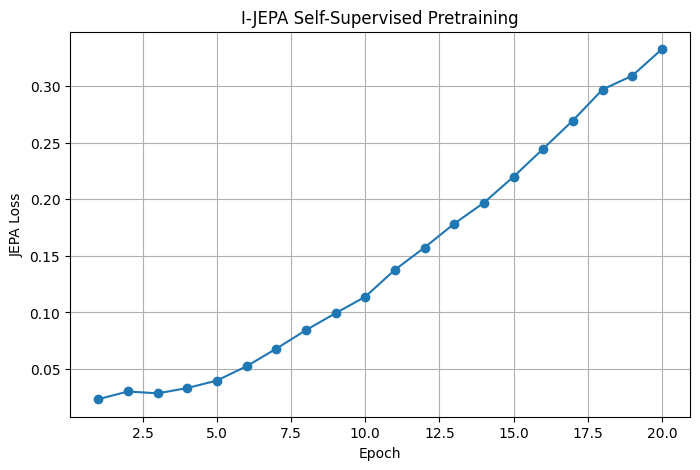

In [53]:
# ============================================================
# CELL 36
# SSL LOSS CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(ssl_history) + 1),
    ssl_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("JEPA Loss")

plt.title(
    "I-JEPA Self-Supervised Pretraining"
)

plt.grid()

plt.show()

In [54]:
# ============================================================
# CELL 37
# LOAD BEST I-JEPA ENCODER
# ============================================================

best_encoder_path = (
    "/kaggle/working/"
    "best_ijepa_encoder.pth"
)

context_encoder.load_state_dict(
    torch.load(
        best_encoder_path,
        map_location=device
    )
)

context_encoder = context_encoder.to(device)

print("Best encoder loaded.")
print("Encoder device:", next(context_encoder.parameters()).device)

Best encoder loaded.
Encoder device: cuda:0


In [55]:
# ============================================================
# CELL 38
# CLASSIFICATION TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (256, 256)
    ),

    transforms.RandomResizedCrop(
        224,
        scale=(0.80, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

print("Transforms ready.")

Transforms ready.


In [57]:
# ============================================================
# CELL 39
# BREAKHIS CLASSIFICATION DATASET
# ============================================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader


class BreakHisClassificationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        # Make a clean copy
        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

        # ----------------------------------------------------
        # Find image-path column automatically
        # ----------------------------------------------------

        possible_path_columns = [
            "image_path",
            "path",
            "filepath",
            "file_path",
            "image",
            "filename"
        ]

        self.path_column = None

        for col in possible_path_columns:

            if col in self.df.columns:

                self.path_column = col
                break

        if self.path_column is None:

            raise ValueError(
                "Could not find image path column.\n"
                f"Available columns: {list(self.df.columns)}"
            )

        # ----------------------------------------------------
        # Find label column automatically
        # ----------------------------------------------------

        possible_label_columns = [
            "label",
            "target",
            "class",
            "y"
        ]

        self.label_column = None

        for col in possible_label_columns:

            if col in self.df.columns:

                self.label_column = col
                break

        if self.label_column is None:

            raise ValueError(
                "Could not find label column.\n"
                f"Available columns: {list(self.df.columns)}"
            )

        print(
            f"Image column : {self.path_column}"
        )

        print(
            f"Label column : {self.label_column}"
        )

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        # ----------------------------------------------------
        # Get image path
        # ----------------------------------------------------

        image_path = self.df.iloc[
            idx
        ][self.path_column]

        # ----------------------------------------------------
        # Open image
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert("RGB")

        # ----------------------------------------------------
        # Apply transform
        # ----------------------------------------------------

        if self.transform is not None:

            image = self.transform(
                image
            )

        # ----------------------------------------------------
        # Get label
        # ----------------------------------------------------

        label = self.df.iloc[
            idx
        ][self.label_column]

        label = int(label)

        return image, label


# ============================================================
# CREATE CLASSIFICATION DATASETS
# ============================================================

train_dataset = BreakHisClassificationDataset(
    train_df,
    transform=train_transform
)

test_dataset = BreakHisClassificationDataset(
    test_df,
    transform=test_transform
)


print()
print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))

Image column : path
Label column : label
Image column : path
Label column : label

Training images: 6327
Testing images : 1582


In [58]:
# ============================================================
# CELL 40 — DATALOADERS
# ============================================================

CLASS_BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=CLASS_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CLASS_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train images :", len(train_dataset))
print("Test images  :", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Train images : 6327
Test images  : 1582
Train batches: 396
Test batches : 99

Train class distribution:
label
0    1984
1    4343
Name: count, dtype: int64

Test class distribution:
label
0     496
1    1086
Name: count, dtype: int64


In [59]:
# ============================================================
# CELL 41 — I-JEPA CLASSIFIER + OPTIMIZER
# ============================================================

class FineTuneClassifier(nn.Module):

    def __init__(
        self,
        encoder,
        embed_dim=384,
        num_classes=2
    ):
        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # [B, 196, 384]
        tokens = self.encoder(x)

        # Global average pooling
        # [B, 384]
        features = tokens.mean(dim=1)

        # [B, 2]
        logits = self.classifier(features)

        return logits


# ------------------------------------------------------------
# Create model using our pretrained I-JEPA encoder
# ------------------------------------------------------------

finetune_model = FineTuneClassifier(
    encoder=context_encoder,
    embed_dim=384,
    num_classes=2
).to(device)


# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer_ft = torch.optim.AdamW(
    [
        {
            "params": finetune_model.encoder.parameters(),
            "lr": 1e-5
        },
        {
            "params": finetune_model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=0.01
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=20
)


print("Model ready.")
print("Class weights:", class_weights)
print("Device:", device)

Model ready.
Class weights: tensor([1.5945, 0.7284], device='cuda:0')
Device: cuda


In [60]:
# ============================================================
# CELL 41 — I-JEPA CLASSIFIER + OPTIMIZER
# ============================================================

class FineTuneClassifier(nn.Module):

    def __init__(
        self,
        encoder,
        embed_dim=384,
        num_classes=2
    ):
        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # [B, 196, 384]
        tokens = self.encoder(x)

        # Global average pooling
        # [B, 384]
        features = tokens.mean(dim=1)

        # [B, 2]
        logits = self.classifier(features)

        return logits


# ------------------------------------------------------------
# Create model using our pretrained I-JEPA encoder
# ------------------------------------------------------------

finetune_model = FineTuneClassifier(
    encoder=context_encoder,
    embed_dim=384,
    num_classes=2
).to(device)


# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer_ft = torch.optim.AdamW(
    [
        {
            "params": finetune_model.encoder.parameters(),
            "lr": 1e-5
        },
        {
            "params": finetune_model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=0.01
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=20
)


print("Model ready.")
print("Class weights:", class_weights)
print("Device:", device)

Model ready.
Class weights: tensor([1.5945, 0.7284], device='cuda:0')
Device: cuda


In [63]:
# ============================================================
# CELL 42 — FINE-TUNING + EARLY STOPPING
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Split TRAIN data into TRAIN + VALIDATION
# ------------------------------------------------------------

train_part, val_part = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Training samples  :", len(train_part))
print("Validation samples:", len(val_part))
print("Test samples      :", len(test_df))


# ------------------------------------------------------------
# 2. Create datasets
# ------------------------------------------------------------

train_ft_dataset = BreakHisClassificationDataset(
    train_part,
    transform=train_transform
)

val_dataset = BreakHisClassificationDataset(
    val_part,
    transform=test_transform
)


# ------------------------------------------------------------
# 3. Create loaders
# ------------------------------------------------------------

train_ft_loader = DataLoader(
    train_ft_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------------------------
# 4. Recalculate class weights using TRAINING portion only
# ------------------------------------------------------------

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_part["label"].values
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)


# ------------------------------------------------------------
# 5. Optimizer
# ------------------------------------------------------------

optimizer_ft = torch.optim.AdamW(
    [
        {
            "params": finetune_model.encoder.parameters(),
            "lr": 1e-5
        },
        {
            "params": finetune_model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=0.01
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=20
)


# ============================================================
# 6. EARLY STOPPING SETTINGS
# ============================================================

MAX_EPOCHS = 20

# Stop after 3 consecutive epochs without improvement
PATIENCE = 3

# Minimum improvement required
MIN_DELTA = 0.0001

best_val_loss = float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}


# ============================================================
# 7. TRAINING
# ============================================================

for epoch in range(MAX_EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    finetune_model.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_ft_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer_ft.zero_grad(
            set_to_none=True
        )

        logits = finetune_model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            finetune_model.parameters(),
            max_norm=1.0
        )

        optimizer_ft.step()

        train_running_loss += loss.item()

        predictions = logits.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    train_loss = (
        train_running_loss /
        len(train_ft_loader)
    )

    train_acc = (
        train_correct /
        train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    finetune_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            logits = finetune_model(images)

            loss = criterion(
                logits,
                labels
            )

            val_running_loss += loss.item()

            predictions = logits.argmax(
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    )


    scheduler.step()


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_acc"].append(
        val_acc
    )


    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}%"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = val_loss

        patience_counter = 0

        torch.save(
            finetune_model.state_dict(),
            "/kaggle/working/"
            "best_ijepa_breakhis_classifier.pth"
        )

        print(
            f"   ★ Validation loss improved → "
            f"{best_val_loss:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"   No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

        if patience_counter >= PATIENCE:

            print(
                "\n🛑 EARLY STOPPING"
            )

            print(
                f"Training stopped at epoch "
                f"{epoch+1}"
            )

            break


print("\n========================================")
print("Fine-tuning completed.")
print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)
print("========================================")

Training samples  : 5377
Validation samples: 950
Test samples      : 1582
Image column : path
Label column : label
Image column : path
Label column : label
Epoch 01/20 | Train Loss: 0.4431 | Val Loss: 0.4169 | Train Acc: 85.81% | Val Acc: 87.58%
   ★ Validation loss improved → 0.4169
Epoch 02/20 | Train Loss: 0.4368 | Val Loss: 0.4058 | Train Acc: 85.92% | Val Acc: 86.74%
   ★ Validation loss improved → 0.4058
Epoch 03/20 | Train Loss: 0.4287 | Val Loss: 0.3827 | Train Acc: 86.00% | Val Acc: 87.58%
   ★ Validation loss improved → 0.3827
Epoch 04/20 | Train Loss: 0.4144 | Val Loss: 0.3719 | Train Acc: 86.44% | Val Acc: 88.00%
   ★ Validation loss improved → 0.3719


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 05/20 | Train Loss: 0.4134 | Val Loss: 0.3702 | Train Acc: 86.59% | Val Acc: 88.11%
   ★ Validation loss improved → 0.3702


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 06/20 | Train Loss: 0.4034 | Val Loss: 0.3670 | Train Acc: 87.45% | Val Acc: 86.53%
   ★ Validation loss improved → 0.3670
Epoch 07/20 | Train Loss: 0.3928 | Val Loss: 0.3591 | Train Acc: 87.39% | Val Acc: 88.11%
   ★ Validation loss improved → 0.3591


...

Epoch 17/20 | Train Loss: 0.3550 | Val Loss: 0.3218 | Train Acc: 89.34% | Val Acc: 89.68%
   ★ Validation loss improved → 0.3218
Epoch 18/20 | Train Loss: 0.3577 | Val Loss: 0.3247 | Train Acc: 88.90% | Val Acc: 89.16%
   No improvement (1/3)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 19/20 | Train Loss: 0.3543 | Val Loss: 0.3238 | Train Acc: 89.08% | Val Acc: 89.47%
   No improvement (2/3)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>^
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
^  ^ ^ ^^  ^ ^^^^^^

Epoch 20/20 | Train Loss: 0.3556 | Val Loss: 0.3233 | Train Acc: 89.12% | Val Acc: 89.47%
   No improvement (3/3)

🛑 EARLY STOPPING
Training stopped at epoch 20

Fine-tuning completed.
Best validation loss: 0.3218


In [64]:
# ============================================================
# CELL 43 — FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

best_model_path = (
    "/kaggle/working/"
    "best_ijepa_breakhis_classifier.pth"
)

finetune_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

finetune_model.eval()

print("Best model loaded.")


# ------------------------------------------------------------
# TEST SET PREDICTIONS
# ------------------------------------------------------------

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        logits = finetune_model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = logits.argmax(
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

auc = roc_auc_score(
    all_labels,
    all_probabilities
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("          I-JEPA + BREAKHIS TEST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Benign",
            "Malignant"
        ],
        zero_division=0
    )
)

Best model loaded.

          I-JEPA + BREAKHIS TEST RESULTS
Accuracy : 89.06%
Precision: 94.19%
Recall   : 89.59%
F1-score : 91.84%
ROC-AUC  : 0.9579

Confusion Matrix:
[[436  60]
 [113 973]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.79      0.88      0.83       496
   Malignant       0.94      0.90      0.92      1086

    accuracy                           0.89      1582
   macro avg       0.87      0.89      0.88      1582
weighted avg       0.90      0.89      0.89      1582



In [66]:
# ============================================================
# CELL 49 — INSPECT ACTUAL BREAKHIS PATHS
# ============================================================

print("DataFrame columns:")
print(df.columns.tolist())

print("\nNumber of images:")
print(len(df))

print("\nFirst 10 image paths:\n")

for i, path in enumerate(df["path"].head(10)):
    print(f"{i+1}. {path}")

print("\nFirst 10 labels:\n")
print(df["label"].head(10).tolist())

print("\nTrain dataframe:")
print(train_df.head())

print("\nTest dataframe:")
print(test_df.head())

DataFrame columns:
['path', 'label']

Number of images:
7909

First 10 image paths:

1. /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-012.png
2. /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-009.png
3. /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-006.png
4. /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-011.png
5. /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-004.png
6. /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_sl

In [67]:
# ============================================================
# CELL 50 — CREATE SPECIMEN/GROUP ID
# ============================================================

import os
import pandas as pd
import numpy as np

df_patient = df.copy()

# Example:
# .../SOB_B_A_14-29960CD/200X/image.png
#
# We extract:
# SOB_B_A_14-29960CD

df_patient["group_id"] = df_patient["path"].apply(
    lambda x: os.path.basename(
        os.path.dirname(x)
    )
)

print("Number of images :", len(df_patient))
print("Number of groups :", df_patient["group_id"].nunique())

print("\nExample:")
print(
    df_patient[
        ["path", "label", "group_id"]
    ].head(10).to_string(index=False)
)

print("\nImages per group:")
print(
    df_patient["group_id"]
    .value_counts()
    .head(10)
)

Number of images : 7909
Number of groups : 4

Example:
                                                                                                                                                               path  label group_id
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-012.png      0     200X
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-009.png      0     200X
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-006.png      0     200X
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-011.png      0     200X
/kaggle/input/datasets/ambarish/breakhis/Brea

In [68]:
# ============================================================
# CELL 51 — GROUP-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

X = df_patient["path"]
y = df_patient["label"]
groups = df_patient["group_id"]

# ------------------------------------------------------------
# FIRST SPLIT
# 80% development / 20% test
# ------------------------------------------------------------

sgkf_test = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

splits_test = list(
    sgkf_test.split(
        X,
        y,
        groups
    )
)

train_val_idx, test_idx = splits_test[0]

train_val_df = df_patient.iloc[
    train_val_idx
].reset_index(drop=True)

patient_test_df = df_patient.iloc[
    test_idx
].reset_index(drop=True)


# ------------------------------------------------------------
# SECOND SPLIT
# 85% train / 15% validation
# of the development data
# ------------------------------------------------------------

sgkf_val = StratifiedGroupKFold(
    n_splits=6,
    shuffle=True,
    random_state=42
)

X_tv = train_val_df["path"]
y_tv = train_val_df["label"]
groups_tv = train_val_df["group_id"]

splits_val = list(
    sgkf_val.split(
        X_tv,
        y_tv,
        groups_tv
    )
)

train_idx, val_idx = splits_val[0]

patient_train_df = train_val_df.iloc[
    train_idx
].reset_index(drop=True)

patient_val_df = train_val_df.iloc[
    val_idx
].reset_index(drop=True)


# ============================================================
# CHECK SPLIT
# ============================================================

print("=" * 60)
print("PATIENT/SPECIMEN-LEVEL SPLIT")
print("=" * 60)

print(
    f"Train images      : {len(patient_train_df)}"
)

print(
    f"Validation images : {len(patient_val_df)}"
)

print(
    f"Test images       : {len(patient_test_df)}"
)

print()

print(
    f"Train groups      : "
    f"{patient_train_df.group_id.nunique()}"
)

print(
    f"Validation groups : "
    f"{patient_val_df.group_id.nunique()}"
)

print(
    f"Test groups       : "
    f"{patient_test_df.group_id.nunique()}"
)


# ------------------------------------------------------------
# Verify NO GROUP OVERLAP
# ------------------------------------------------------------

train_groups = set(
    patient_train_df.group_id
)

val_groups = set(
    patient_val_df.group_id
)

test_groups = set(
    patient_test_df.group_id
)

print("\nGroup overlap:")

print(
    "Train ∩ Validation:",
    len(train_groups & val_groups)
)

print(
    "Train ∩ Test:",
    len(train_groups & test_groups)
)

print(
    "Validation ∩ Test:",
    len(val_groups & test_groups)
)


# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

print("\nClass distribution:")

print(
    "\nTRAIN:"
)

print(
    patient_train_df["label"]
    .value_counts()
    .sort_index()
)

print(
    "\nVALIDATION:"
)

print(
    patient_val_df["label"]
    .value_counts()
    .sort_index()
)

print(
    "\nTEST:"
)

print(
    patient_test_df["label"]
    .value_counts()
    .sort_index()
)

PATIENT/SPECIMEN-LEVEL SPLIT
Train images      : 4008
Validation images : 2081
Test images       : 1820

Train groups      : 2
Validation groups : 1
Test groups       : 1

Group overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Class distribution:

TRAIN:
label
0    1248
1    2760
Name: count, dtype: int64

VALIDATION:
label
0     644
1    1437
Name: count, dtype: int64

TEST:
label
0     588
1    1232
Name: count, dtype: int64


In [69]:
# ============================================================
# CELL 52 — PATIENT-LEVEL DATASETS
# ============================================================

patient_train_dataset = BreakHisClassificationDataset(
    patient_train_df,
    transform=train_transform
)

patient_val_dataset = BreakHisClassificationDataset(
    patient_val_df,
    transform=test_transform
)

patient_test_dataset = BreakHisClassificationDataset(
    patient_test_df,
    transform=test_transform
)


patient_train_loader = DataLoader(
    patient_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

patient_val_loader = DataLoader(
    patient_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

patient_test_loader = DataLoader(
    patient_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Patient-level loaders ready.")

print(
    "Train batches:",
    len(patient_train_loader)
)

print(
    "Validation batches:",
    len(patient_val_loader)
)

print(
    "Test batches:",
    len(patient_test_loader)
)

Image column : path
Label column : label
Image column : path
Label column : label
Image column : path
Label column : label
Patient-level loaders ready.
Train batches: 251
Validation batches: 131
Test batches: 114


In [71]:
# ============================================================
# CELL 53 — FRESH PATIENT-LEVEL CLASSIFIER
# FIXED VERSION
# ============================================================

import copy

# ------------------------------------------------------------
# Create a completely separate copy of the encoder
# ------------------------------------------------------------

context_encoder_patient = copy.deepcopy(
    context_encoder
).to(device)


# ------------------------------------------------------------
# Load the best SSL encoder checkpoint
# ------------------------------------------------------------

ssl_checkpoint = (
    "/kaggle/working/"
    "best_ijepa_encoder.pth"
)

context_encoder_patient.load_state_dict(
    torch.load(
        ssl_checkpoint,
        map_location=device
    )
)


# ------------------------------------------------------------
# Create a NEW classification model
# ------------------------------------------------------------

patient_model = FineTuneClassifier(
    encoder=context_encoder_patient,
    embed_dim=384,
    num_classes=2
).to(device)


print("=" * 55)
print("Patient-level classifier created")
print("=" * 55)

print(
    "Encoder parameters:",
    sum(
        p.numel()
        for p in context_encoder_patient.parameters()
    )
)

print(
    "Total model parameters:",
    sum(
        p.numel()
        for p in patient_model.parameters()
    )
)

print(
    "Device:",
    device
)

Patient-level classifier created
Encoder parameters: 11018112
Total model parameters: 11117954
Device: cuda


In [72]:
# ============================================================
# CELL 54 — PATIENT-LEVEL LOSS + OPTIMIZER
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Class weights from TRAINING GROUPS ONLY
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=patient_train_df["label"].values
)

patient_class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

# Classification loss
patient_criterion = nn.CrossEntropyLoss(
    weight=patient_class_weights,
    label_smoothing=0.05
)

# Different learning rates:
# encoder = small LR
# classifier = larger LR
patient_optimizer = torch.optim.AdamW(
    [
        {
            "params": patient_model.encoder.parameters(),
            "lr": 1e-5
        },
        {
            "params": patient_model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=0.01
)

patient_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    patient_optimizer,
    T_max=20
)

print("Class weights:", patient_class_weights)
print("Optimizer ready.")

Class weights: tensor([1.6058, 0.7261], device='cuda:0')
Optimizer ready.


In [73]:
# ============================================================
# CELL 55 — PATIENT-LEVEL FINE-TUNING
# ============================================================

MAX_EPOCHS = 20
PATIENCE = 3
MIN_DELTA = 0.0001

best_val_loss = float("inf")
patience_counter = 0

patient_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(MAX_EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    patient_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in patient_train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        patient_optimizer.zero_grad(
            set_to_none=True
        )

        logits = patient_model(images)

        loss = patient_criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            patient_model.parameters(),
            max_norm=1.0
        )

        patient_optimizer.step()

        train_loss_sum += loss.item()

        predictions = logits.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        train_loss_sum /
        len(patient_train_loader)
    )

    train_acc = (
        train_correct /
        train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    patient_model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in patient_val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            logits = patient_model(images)

            loss = patient_criterion(
                logits,
                labels
            )

            val_loss_sum += loss.item()

            predictions = logits.argmax(
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = (
        val_loss_sum /
        len(patient_val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    )

    patient_scheduler.step()


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    patient_history["train_loss"].append(
        train_loss
    )

    patient_history["val_loss"].append(
        val_loss
    )

    patient_history["train_acc"].append(
        train_acc
    )

    patient_history["val_acc"].append(
        val_acc
    )


    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}%"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            patient_model.state_dict(),
            "/kaggle/working/"
            "best_patient_ijepa_classifier.pth"
        )

        print(
            f"   ★ Best validation loss: "
            f"{best_val_loss:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"   No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

        if patience_counter >= PATIENCE:

            print("\n🛑 EARLY STOPPING")
            print(
                f"Stopped at epoch {epoch+1}"
            )
            break


print("\n========================================")
print("Patient-level training completed.")
print(
    f"Best validation loss: {best_val_loss:.4f}"
)
print("========================================")

Epoch 01/20 | Train Loss: 0.5297 | Val Loss: 0.5072 | Train Acc: 80.91% | Val Acc: 82.41%
   ★ Best validation loss: 0.5072


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    Exception ignored in: assert self._parent_pid == os.getpid(), 'can only test a child process'<function _MultiProcessingDataLoaderIter.__del__ at 0x7a03c919b420>

 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
  ^ ^  ^ ^ ^ ^^^^^^^^^^^^^^^^^^^^

Epoch 02/20 | Train Loss: 0.5166 | Val Loss: 0.5188 | Train Acc: 82.49% | Val Acc: 81.50%
   No improvement (1/3)


KeyboardInterrupt: 